# Domain-adapted encoders (TSDAE checkpoints)

Evaluates the `multilingual-e5-small` checkpoints adapted with TSDAE
(`scripts/run_tsdae.py`), frozen, with the same classical regressor search as
notebooks 01 and 02. Participant level only, so the comparison is against
`E2_E5SMALL` in the shared log: same base checkpoint, same representation,
same downstream procedure — the only difference is the adaptation.

Two corpus variants, each with its own arms so their embedding caches and log
rows never collide:

- `E3_TSDAE_EPxx`: adapted on the interview transcriptions alone;
- `E3_TSDAE_MR_EPxx`: interviews plus the MentalRiskES patient messages.

**Every declared checkpoint is reported**, whichever wins. Adaptation length
is being described as a curve, not selected: picking the best-scoring epoch
on the held-out set would be choosing the encoder on the outcome it is meant
to be evaluated against (PROTOCOL.md, Section 9).

**All metrics below are on the held-out test participants.** Cross-validation
numbers appear only where labelled, and reflect model selection on training
data.

In [7]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src import config, data, splits, logging_utils
from src.pipeline import TARGETS, build_train_frame, compute_checkpoint_embeddings, \
    encoder_data, run_encoder, search_label
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run configuration

In [8]:
# One entry per corpus variant: arm prefix and adaptation directory. The
# directories come from config.TSDAE_CORPORA, the same table run_tsdae.py
# writes them from.
VARIANTS = {
    "interviews": (
        "E3_TSDAE",
        config.MODELS_DIR / config.TSDAE_CORPORA[(config.CORPUS_INTERVIEWS,)]),
    "interviews+mentalriskes": (
        "E3_TSDAE_MR",
        config.MODELS_DIR / config.TSDAE_CORPORA[(config.CORPUS_INTERVIEWS, config.CORPUS_MENTALRISKES)]),
}
# Declared before running, and all four are reported for every variant.
EPOCHS = (5, 10, 20, 30)

CHECKPOINTS = {f"{prefix}_EP{epoch:02d}": adapted_dir / f"ep{epoch:02d}"
               for prefix, adapted_dir in VARIANTS.values() for epoch in EPOCHS}
BASELINE = "E2_E5SMALL"   # same base checkpoint, unadapted, already in the log

missing = [name for name, path in CHECKPOINTS.items() if not path.exists()]
if missing:
    raise SystemExit(f"Missing checkpoints: {missing}. Run scripts/run_tsdae.py first.")

cfg = config.TrainingConfig(
    augmentation=config.AUGMENTATION_NONE,
    seeds=(42,),
    n_cv_splits=5,
    n_search_iter=0,      # 0 = sin busqueda; ver tune_model para afinar una familia
    max_tokens=512,
    chunk_stride=256,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
print("arms:", list(CHECKPOINTS))
cfg

device: cuda
arms: ['E3_TSDAE_EP05', 'E3_TSDAE_EP10', 'E3_TSDAE_EP20', 'E3_TSDAE_EP30', 'E3_TSDAE_MR_EP05', 'E3_TSDAE_MR_EP10', 'E3_TSDAE_MR_EP20', 'E3_TSDAE_MR_EP30']


TrainingConfig(augmentation='no_augmentation', seeds=(42,), n_cv_splits=5, n_search_iter=0, beto_model='dccuchile/bert-base-spanish-wwm-cased', sentence_transformer_model='intfloat/multilingual-e5-small', max_tokens=512, chunk_stride=256, tfidf_max_features=300, tfidf_ngram_range=(1, 2), tfidf_min_df=3, tfidf_max_df=0.9, tfidf_lemmatize=True, tfidf_normalize_numbers=True)

In [9]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, groups = build_train_frame(df, train_ids, test_ids, cfg)
test_frame = df.loc[test_ids]
N_TEST = len(test_frame)
print(f"train: {len(train_frame)} rows, test: {N_TEST} held-out participants")

train: 110 rows, test: 48 held-out participants


One embedding matrix per checkpoint, cached under `results/<augmentation>/embeddings/`.

In [10]:
run_dir = config.results_dir(cfg.augmentation)
combined = pd.concat([train_frame[config.QUESTIONS], test_frame[config.QUESTIONS]])

embeddings = compute_checkpoint_embeddings(combined, device, cfg, run_dir, CHECKPOINTS)
for name, matrix in embeddings.items():
    print(f"{name}: {matrix.shape}")

E3_TSDAE_EP05: (158, 384)
E3_TSDAE_EP10: (158, 384)
E3_TSDAE_EP20: (158, 384)
E3_TSDAE_EP30: (158, 384)
E3_TSDAE_MR_EP05: (158, 384)
E3_TSDAE_MR_EP10: (158, 384)
E3_TSDAE_MR_EP20: (158, 384)
E3_TSDAE_MR_EP30: (158, 384)


In [11]:
def report_encoder(encoder_name, run_rows):
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {encoder_name}: metrics on the {N_TEST} held-out participants, per seed")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    # Filtered to this run's search regime: a defaults run and an earlier
    # tuned run of the same arm both live in the log, and pivoting over both
    # would collide on (model_name, seed).
    trials = logging_utils.load_trials(cfg.augmentation)
    trials = trials[(trials["encoder"] == encoder_name)
                    & (trials["search"] == search_label(cfg))]
    for target in TARGETS:
        print(f"[CROSS-VALIDATION on training data] RMSE per candidate regressor ({target}). "
              f"This is what model selection used; it is not a test score.")
        display(trials[trials["target"] == target].pivot(
            index="model_name", columns="seed", values="cv_rmse").round(3))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best_row = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best_row["seed"])
        plot_confusion_matrix(axes[i, 0], best_row["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best_row["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening (seed={seed})")
    plt.suptitle(f"[TEST] {encoder_name}: confusion matrices, best seed per target")
    plt.tight_layout()
    plt.show()


def train_and_report(encoder_name):
    X_all, preprocessor = encoder_data(encoder_name, combined, None, embeddings, cfg)
    X_train_enc = X_all.loc[train_frame.index]
    X_test_enc = X_all.loc[test_frame.index]
    t0 = time.time()
    run_rows = run_encoder(encoder_name, X_train_enc, X_test_enc, preprocessor,
                            train_frame, test_frame, groups, cfg, notebook="03",
                            encoder_model=str(CHECKPOINTS[encoder_name]))
    print(f"{encoder_name} done in {(time.time()-t0)/60:.1f} min")
    report_encoder(encoder_name, run_rows)

### TSDAE, 5 epochs

E3_TSDAE_EP05 seed=42 target=PHQ9 best=SVR rmse=5.285 r2=0.075 (21.4s)
E3_TSDAE_EP05 seed=42 target=GAD7 best=SVR rmse=4.672 r2=0.138 (21.2s)
E3_TSDAE_EP05 done in 0.7 min
[TEST] E3_TSDAE_EP05: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.672  5.285  3.798  4.341  0.138  0.075

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.664
DecisionTree,7.181
ExtraTrees,5.598
GradientBoosting,5.891
KNN,5.641
LightGBM,5.851
RandomForest,5.641
Ridge,7.080
SVR,5.488


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.642
DecisionTree,6.913
ExtraTrees,4.645
GradientBoosting,4.886
KNN,4.701
LightGBM,4.885
RandomForest,4.610
Ridge,5.855
SVR,4.596


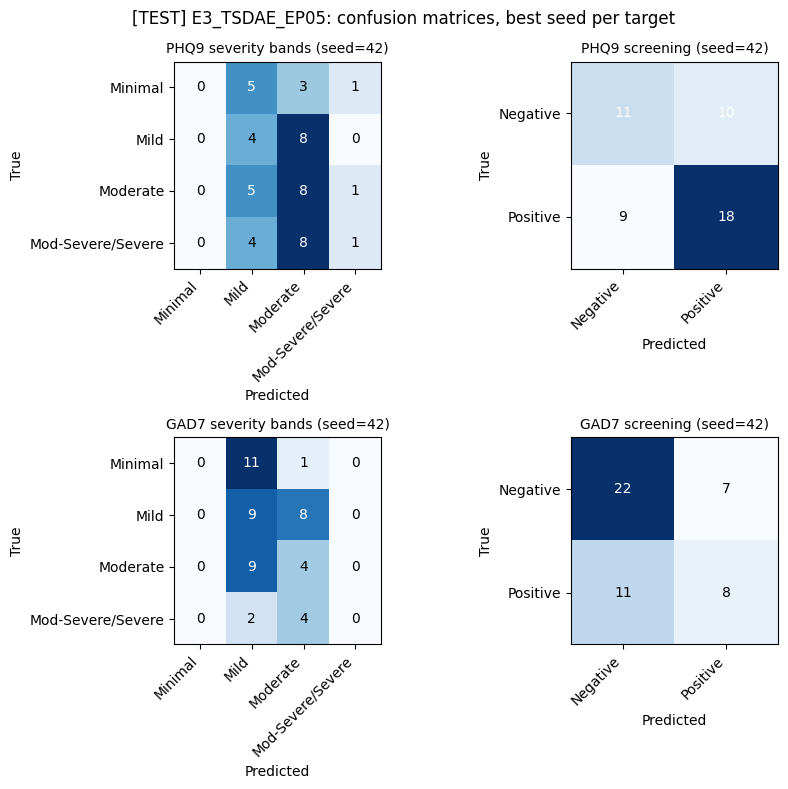

In [12]:
train_and_report("E3_TSDAE_EP05")

### TSDAE, 10 epochs

E3_TSDAE_EP10 seed=42 target=PHQ9 best=SVR rmse=5.280 r2=0.077 (21.5s)
E3_TSDAE_EP10 seed=42 target=GAD7 best=SVR rmse=4.689 r2=0.131 (21.1s)
E3_TSDAE_EP10 done in 0.7 min
[TEST] E3_TSDAE_EP10: metrics on the 48 held-out participants, per seed


rmse         mae            r2       
target   GAD7  PHQ9  GAD7   PHQ9   GAD7   PHQ9
seed                                          
42      4.689  5.28  3.83  4.375  0.131  0.077

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.843
DecisionTree,7.706
ExtraTrees,5.642
GradientBoosting,5.750
KNN,5.574
LightGBM,6.157
RandomForest,5.654
Ridge,6.507
SVR,5.488


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.701
DecisionTree,6.175
ExtraTrees,4.722
GradientBoosting,4.815
KNN,4.651
LightGBM,4.842
RandomForest,4.636
Ridge,5.561
SVR,4.604


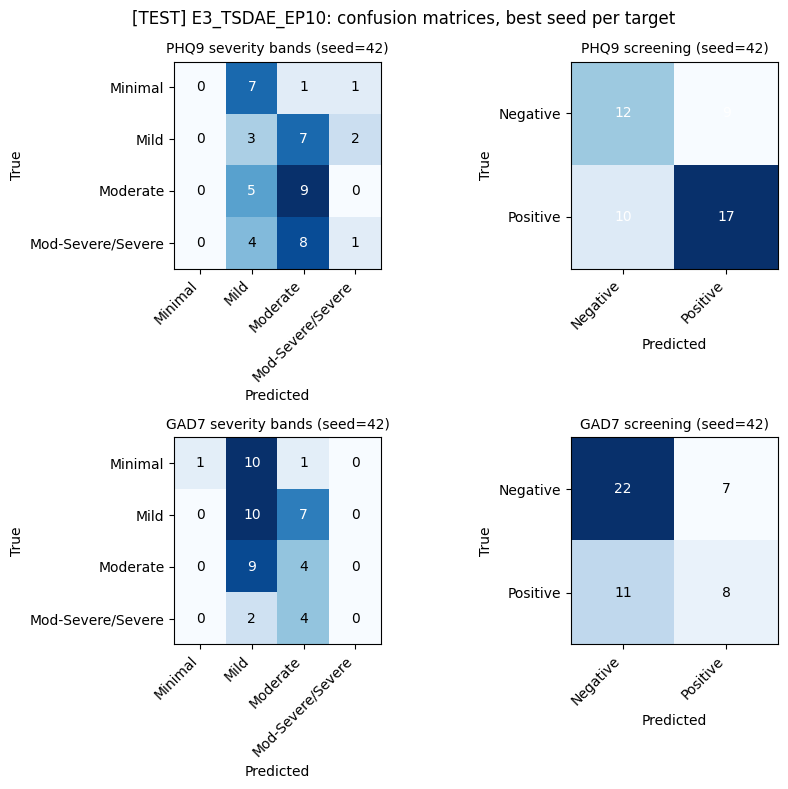

In [13]:
train_and_report("E3_TSDAE_EP10")

### TSDAE, 20 epochs

E3_TSDAE_EP20 seed=42 target=PHQ9 best=SVR rmse=5.126 r2=0.130 (21.2s)
E3_TSDAE_EP20 seed=42 target=GAD7 best=LightGBM rmse=4.668 r2=0.139 (21.0s)
E3_TSDAE_EP20 done in 0.7 min
[TEST] E3_TSDAE_EP20: metrics on the 48 held-out participants, per seed


rmse           mae           r2      
target   GAD7   PHQ9   GAD7  PHQ9   GAD7  PHQ9
seed                                          
42      4.668  5.126  3.792  4.24  0.139  0.13

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.677
DecisionTree,7.785
ExtraTrees,5.656
GradientBoosting,5.773
KNN,5.700
LightGBM,6.000
RandomForest,5.633
Ridge,7.380
SVR,5.595


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.509
DecisionTree,5.930
ExtraTrees,4.607
GradientBoosting,4.662
KNN,4.680
LightGBM,4.507
RandomForest,4.689
Ridge,5.985
SVR,4.611


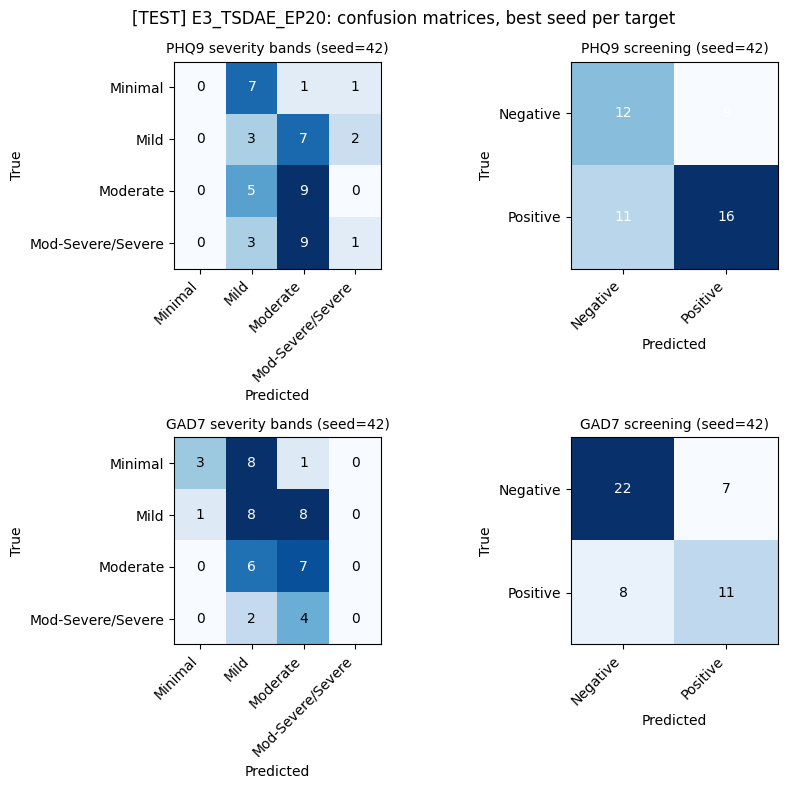

In [14]:
train_and_report("E3_TSDAE_EP20")

### TSDAE, 30 epochs

E3_TSDAE_EP30 seed=42 target=PHQ9 best=LightGBM rmse=5.509 r2=-0.005 (21.2s)
E3_TSDAE_EP30 seed=42 target=GAD7 best=AdaBoost rmse=4.615 r2=0.158 (21.2s)
E3_TSDAE_EP30 done in 0.7 min
[TEST] E3_TSDAE_EP30: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.615  5.509  3.809  4.601  0.158 -0.005

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.587
DecisionTree,7.066
ExtraTrees,5.676
GradientBoosting,5.488
KNN,5.583
LightGBM,5.383
RandomForest,5.570
Ridge,6.989
SVR,5.528


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.262
DecisionTree,6.306
ExtraTrees,4.636
GradientBoosting,4.378
KNN,4.610
LightGBM,4.530
RandomForest,4.571
Ridge,5.757
SVR,4.594


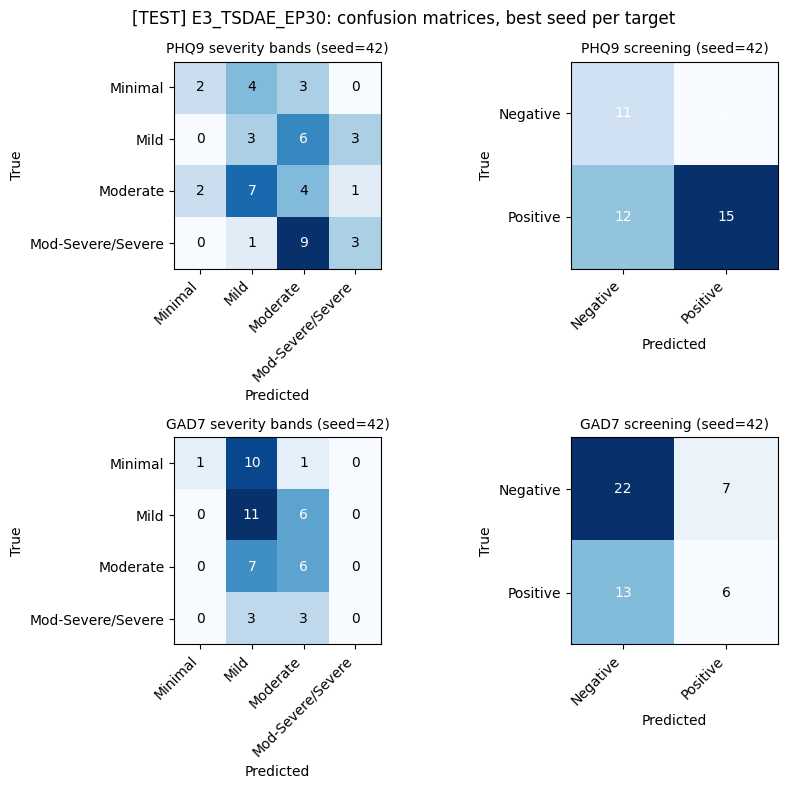

In [15]:
train_and_report("E3_TSDAE_EP30")

### TSDAE + MentalRiskES, 5 epochs

E3_TSDAE_MR_EP05 seed=42 target=PHQ9 best=SVR rmse=5.296 r2=0.071 (21.1s)
E3_TSDAE_MR_EP05 seed=42 target=GAD7 best=SVR rmse=4.648 r2=0.146 (21.1s)
E3_TSDAE_MR_EP05 done in 0.7 min
[TEST] E3_TSDAE_MR_EP05: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.648  5.296  3.725  4.317  0.146  0.071

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.486
DecisionTree,8.198
ExtraTrees,5.591
GradientBoosting,5.660
KNN,5.611
LightGBM,6.162
RandomForest,5.598
Ridge,6.768
SVR,5.451


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.602
DecisionTree,5.981
ExtraTrees,4.643
GradientBoosting,4.798
KNN,4.753
LightGBM,4.704
RandomForest,4.566
Ridge,5.787
SVR,4.528


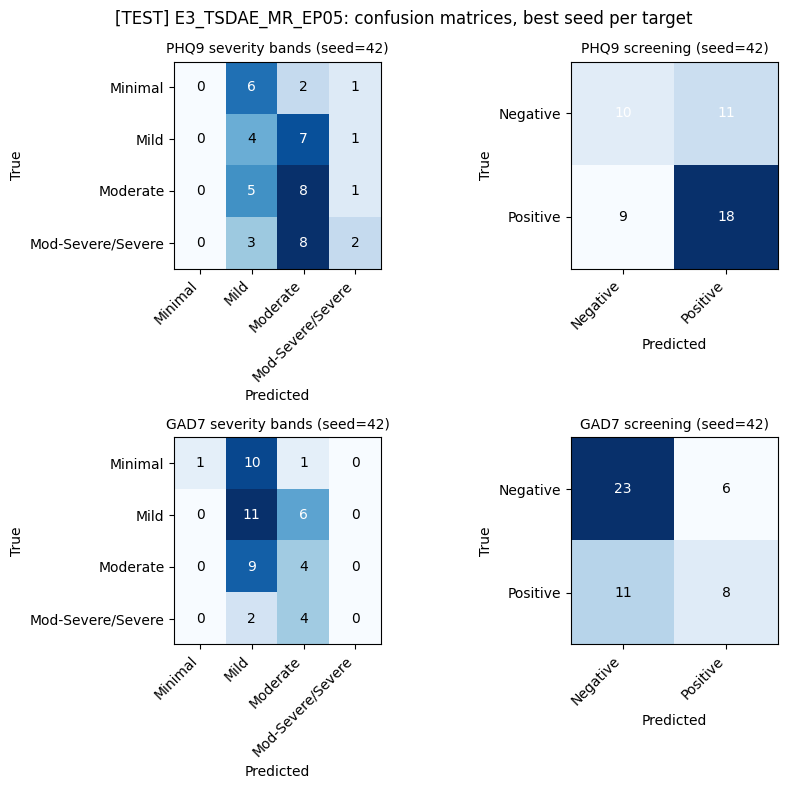

In [16]:
train_and_report("E3_TSDAE_MR_EP05")

### TSDAE + MentalRiskES, 10 epochs

E3_TSDAE_MR_EP10 seed=42 target=PHQ9 best=SVR rmse=5.312 r2=0.066 (21.0s)
E3_TSDAE_MR_EP10 seed=42 target=GAD7 best=LightGBM rmse=4.987 r2=0.018 (21.6s)
E3_TSDAE_MR_EP10 done in 0.7 min
[TEST] E3_TSDAE_MR_EP10: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.987  5.312  4.122  4.279  0.018  0.066

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.848
DecisionTree,6.959
ExtraTrees,5.679
GradientBoosting,5.963
KNN,5.679
LightGBM,6.387
RandomForest,5.666
Ridge,7.658
SVR,5.626


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.422
DecisionTree,6.131
ExtraTrees,4.588
GradientBoosting,4.547
KNN,4.699
LightGBM,4.372
RandomForest,4.608
Ridge,6.090
SVR,4.549


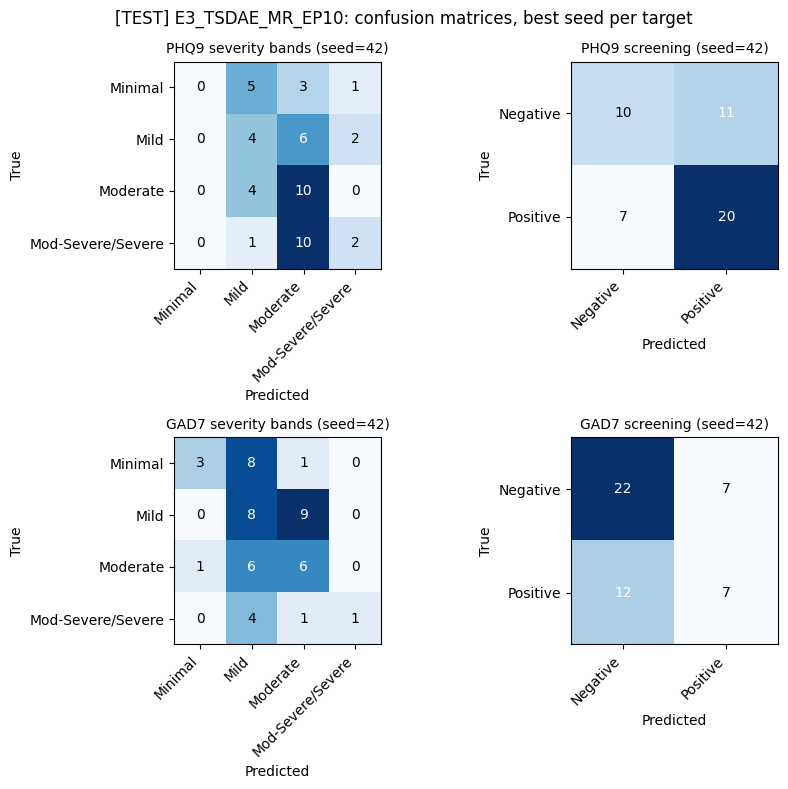

In [17]:
train_and_report("E3_TSDAE_MR_EP10")

### TSDAE + MentalRiskES, 20 epochs

E3_TSDAE_MR_EP20 seed=42 target=PHQ9 best=ExtraTrees rmse=5.235 r2=0.092 (21.3s)
E3_TSDAE_MR_EP20 seed=42 target=GAD7 best=GradientBoosting rmse=4.607 r2=0.161 (21.3s)
E3_TSDAE_MR_EP20 done in 0.7 min
[TEST] E3_TSDAE_MR_EP20: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.607  5.235  3.833  4.244  0.161  0.092

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.682
DecisionTree,7.899
ExtraTrees,5.629
GradientBoosting,5.719
KNN,6.023
LightGBM,5.731
RandomForest,5.661
Ridge,7.826
SVR,5.747


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.418
DecisionTree,5.423
ExtraTrees,4.645
GradientBoosting,4.313
KNN,4.862
LightGBM,4.549
RandomForest,4.569
Ridge,6.243
SVR,4.702


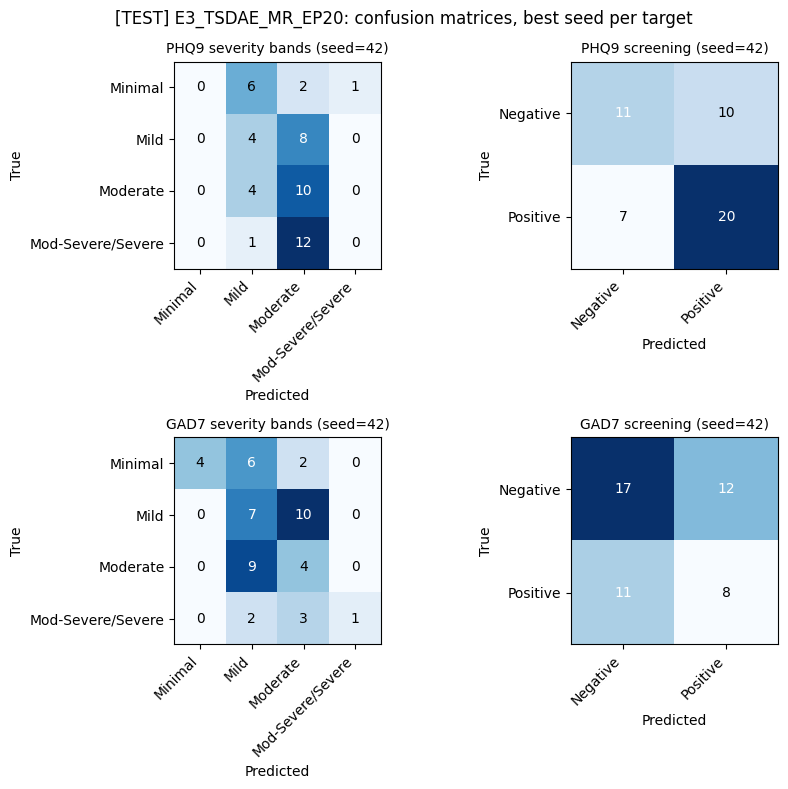

In [18]:
train_and_report("E3_TSDAE_MR_EP20")

### TSDAE + MentalRiskES, 30 epochs

E3_TSDAE_MR_EP30 seed=42 target=PHQ9 best=RandomForest rmse=5.075 r2=0.147 (21.1s)
E3_TSDAE_MR_EP30 seed=42 target=GAD7 best=AdaBoost rmse=4.424 r2=0.227 (21.1s)
E3_TSDAE_MR_EP30 done in 0.7 min
[TEST] E3_TSDAE_MR_EP30: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.424  5.075  3.561  4.198  0.227  0.147

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.850
DecisionTree,7.364
ExtraTrees,5.644
GradientBoosting,5.953
KNN,5.888
LightGBM,6.301
RandomForest,5.631
Ridge,8.810
SVR,5.675


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.439
DecisionTree,5.566
ExtraTrees,4.609
GradientBoosting,4.553
KNN,4.799
LightGBM,4.597
RandomForest,4.572
Ridge,7.027
SVR,4.652


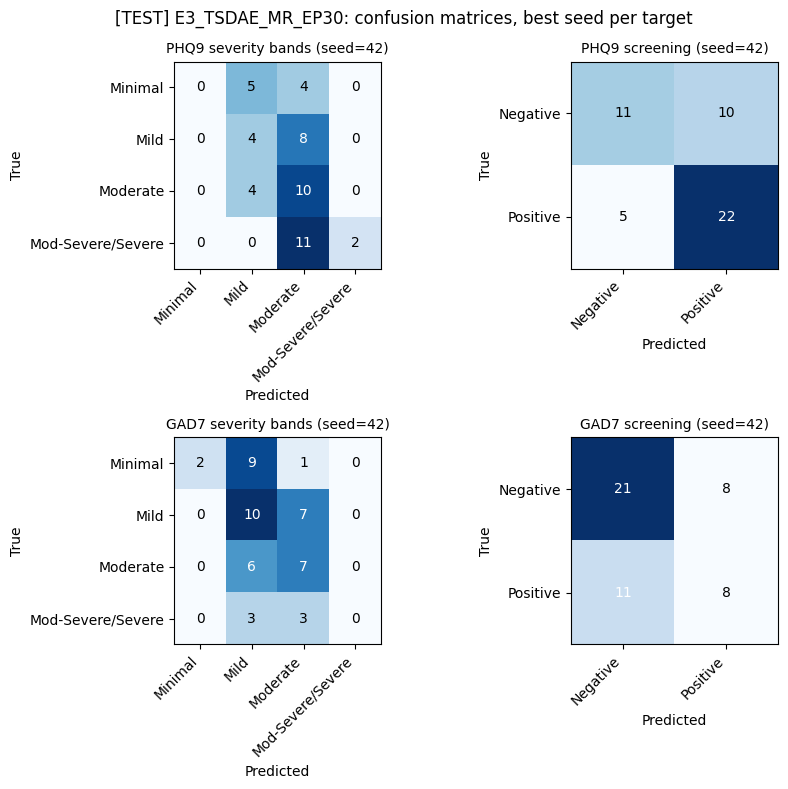

In [19]:
train_and_report("E3_TSDAE_MR_EP30")

### Adaptation curves against the unadapted baseline

`E2_E5SMALL` is the same checkpoint without adaptation, already measured on
the same participants, so the difference isolates what TSDAE did. One curve
per corpus variant, both starting from that same point at epoch 0.

In [20]:
log = logging_utils.load_all_runs()
log = log[log.augmentation == cfg.augmentation]
order = [BASELINE] + list(CHECKPOINTS)
# `search` is part of the grouping: the same arm can appear both with and
# without hyperparameter search, and averaging across the two would pool
# results from different procedures into one meaningless number.
summary = log[log.encoder.isin(order)].groupby(["encoder", "search", "target"])[
    ["rmse", "mae", "r2"]].agg(["mean", "std"]).round(3)

spread = (f"mean and SD across {len(cfg.seeds)} seeds" if len(cfg.seeds) > 1
          else f"single seed ({cfg.seeds[0]}), so the SD columns are empty")
print(f"[TEST] {spread}, on the {N_TEST} held-out participants.")
print("RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of")
print("variance explained (0 = no better than predicting the training mean).")
present = set(summary.index.get_level_values("encoder"))
display(summary.loc[[e for e in order if e in present]])

[TEST] single seed (42), so the SD columns are empty, on the 48 held-out participants.
RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of
variance explained (0 = no better than predicting the training mean).


rmse        mae         r2    
                                   mean std   mean std   mean std
encoder          search   target                                 
E2_E5SMALL       defaults GAD7    4.563 NaN  3.756 NaN  0.178 NaN
                          PHQ9    4.830 NaN  3.912 NaN  0.227 NaN
E3_TSDAE_EP05    defaults GAD7    4.672 NaN  3.798 NaN  0.138 NaN
                          PHQ9    5.285 NaN  4.341 NaN  0.075 NaN
E3_TSDAE_EP10    defaults GAD7    4.689 NaN  3.830 NaN  0.131 NaN
                          PHQ9    5.280 NaN  4.375 NaN  0.077 NaN
E3_TSDAE_EP20    defaults GAD7    4.668 NaN  3.792 NaN  0.139 NaN
                          PHQ9    5.126 NaN  4.240 NaN  0.130 NaN
E3_TSDAE_EP30    defaults GAD7    4.615 NaN  3.809 NaN  0.158 NaN
                          PHQ9    5.509 NaN  4.601 NaN -0.005 NaN
E3_TSDAE_MR_EP05 defaults GAD7    4.648 NaN  3.725 NaN  0.146 NaN
                          PHQ9    5.296 NaN  4.317 NaN  0.071 NaN
E3_TSDAE_MR_EP10 defaults GAD7    4.987 NaN  4.122 NaN  0.018 NaN
                          PHQ9    5.312 NaN  4.279 NaN  0.066 NaN
E3_TSDAE_MR_EP20 defaults GAD7    4.607 NaN  3.833 NaN  0.161 NaN
                          PHQ9    5.235 NaN  4.244 NaN  0.092 NaN
E3_TSDAE_MR_EP30 defaults GAD7    4.424 NaN  3.561 NaN  0.227 NaN
                          PHQ9    5.075 NaN  4.198 NaN  0.147 NaN

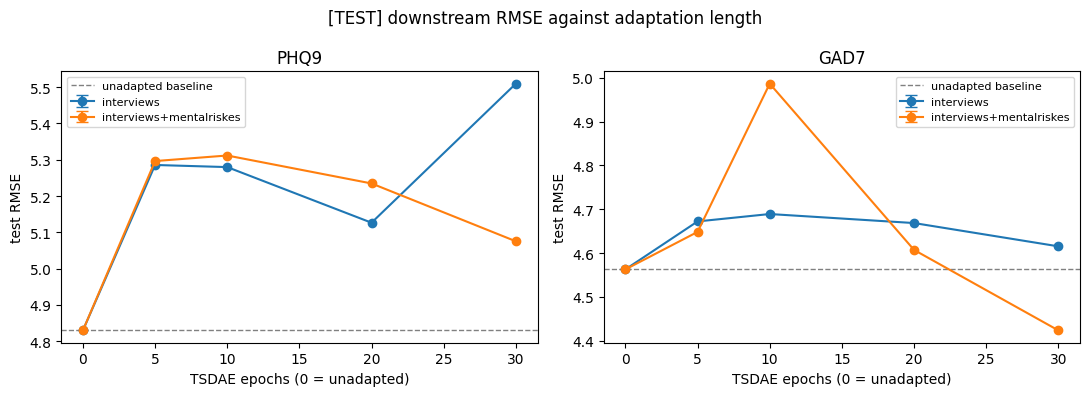

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, target in zip(axes, TARGETS):
    # One regime per curve: mixing tuned and defaults runs would put points
    # from two different procedures on the same line.
    rows = log[(log.target == target) & (log.encoder.isin(order))
                & (log.search == search_label(cfg))]
    means = rows.groupby("encoder")["rmse"].mean()
    sds = rows.groupby("encoder")["rmse"].std()
    for variant, (prefix, _) in VARIANTS.items():
        arms = [BASELINE] + [f"{prefix}_EP{epoch:02d}" for epoch in EPOCHS]
        present = [arm for arm in arms if arm in means.index]
        x = [0 if arm == BASELINE else int(arm[-2:]) for arm in present]
        ax.errorbar(x, means[present], yerr=sds[present], marker="o", capsize=4, label=variant)
    ax.axhline(means.get(BASELINE, float("nan")), linestyle="--", linewidth=1,
                color="grey", label="unadapted baseline")
    ax.set_xlabel("TSDAE epochs (0 = unadapted)")
    ax.set_ylabel("test RMSE")
    ax.set_title(target)
    ax.legend(fontsize=8)

plt.suptitle("[TEST] downstream RMSE against adaptation length"
             + (", mean +/- SD over seeds" if len(cfg.seeds) > 1 else ""))
plt.tight_layout()
plt.show()